# **Regression tutorial**
In today's tutorial we will design and train deep neural networks to solve a regression problem.

We will use [**TensorFlow**](https://www.tensorflow.org/) framework and [**Keras**](https://keras.io/) open-source library to rapidly prototype deep neural networks.

# **Preliminary operations**
The following code downloads all the necessary material into the remote machine. At the end of the execution select the **File** tab to verify that everything has been correctly downloaded.

In [1]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00501/PRSA2017_Data_20130301-20170228.zip

!unzip -q PRSA2017_Data_20130301-20170228.zip

!rm PRSA2017_Data_20130301-20170228.zip

--2026-04-16 15:15:20--  https://archive.ics.uci.edu/ml/machine-learning-databases/00501/PRSA2017_Data_20130301-20170228.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘PRSA2017_Data_20130301-20170228.zip’

PRSA2017_Data_20130     [              <=>   ]   7.59M   124KB/s    in 70s     

2026-04-16 15:16:31 (111 KB/s) - ‘PRSA2017_Data_20130301-20170228.zip’ saved [7959991]



# **Useful modules import**
First of all, it is necessary to import useful modules used during the tutorial.

In [2]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression

# **Utility functions**
Execute the following code to define some utility functions used in the tutorial:
- **plot_history** draws in a graph the loss trend over epochs on both training and validation sets. Moreover, if provided, it draws in the same graph also the trend of the given metric;
- **plot_prediction_results** plots the predicted and the true values and visualizes the error distribution.

In [3]:
def plot_history(history,metric=None):
  fig, ax1 = plt.subplots(figsize=(10, 8))

  epoch_count=len(history.history['loss'])

  line1,=ax1.plot(range(1,epoch_count+1),history.history['loss'],label='train_loss',color='orange')
  ax1.plot(range(1,epoch_count+1),history.history['val_loss'],label='val_loss',color = line1.get_color(), linestyle = '--')
  ax1.set_xlim([1,epoch_count])
  ax1.set_ylim([0, max(max(history.history['loss']),max(history.history['val_loss']))])
  ax1.set_ylabel('loss',color = line1.get_color())
  ax1.tick_params(axis='y', labelcolor=line1.get_color())
  ax1.set_xlabel('Epochs')
  _=ax1.legend(loc='lower left')

  if (metric!=None):
    ax2 = ax1.twinx()
    line2,=ax2.plot(range(1,epoch_count+1),history.history[metric],label='train_'+metric)
    ax2.plot(range(1,epoch_count+1),history.history['val_'+metric],label='val_'+metric,color = line2.get_color(), linestyle = '--')
    ax2.set_ylim([0, max(max(history.history[metric]),max(history.history['val_'+metric]))])
    ax2.set_ylabel(metric,color=line2.get_color())
    ax2.tick_params(axis='y', labelcolor=line2.get_color())
    _=ax2.legend(loc='upper right')

def plot_prediction_results(y,y_pred,output_labels,bin_count=50):
  fig, axs = plt.subplots(2,len(output_labels),figsize=(25, 10),squeeze=False)

  for i in range(len(output_labels)):
    axs[0,i].set_title(output_labels[i])
    axs[0,i].scatter(y[:,i], y_pred[:,i],s=1)
    axs[0,i].set_xlabel('True Values')
    if i==0:
      axs[0,i].set_ylabel('Predictions')
    max_value=max(max(y[:,i]),max(y_pred[:,i]))
    x_lims = [0, max_value]
    y_lims = [min(0,min(y[:,i]),min(y_pred[:,i])), max_value]
    axs[0,i].set_xlim(x_lims)
    axs[0,i].set_ylim(y_lims)
    axs[0,i].plot(y_lims, y_lims, color='k')

    errors = y[:,i]-y_pred[:,i]
    axs[1,i].hist(errors, bins=bin_count)
    axs[1,i].set_xlabel('Prediction Error')
    if i==0:
      axs[1,i].set_ylabel('Count')
    axs[1,i].set_xlim([min(errors),max(errors)])

# **Dataset**
This tutorial uses the [Beijing Multi-Site Air-Quality Data Data Set](https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data) maintained by the [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php), a public repository containing hundreds of databases useful for the machine learning community.

The data set includes hourly air pollutants data from 12 nationally-controlled air-quality monitoring sites of the Beijing municipal environmental monitoring center. It contains 420768 istances with 18 attributes:
- *No*: row number
- *year*: year of data
- *month*: month of data
- *day*: day of data
- *hour*: hour of data
- *PM2.5*: PM2.5 concentration (ug/m^3)
- *PM10*: PM10 concentration (ug/m^3)
- *SO2*: SO2 concentration (ug/m^3)
- *NO2*: NO2 concentration (ug/m^3)
- *CO*: CO concentration (ug/m^3)
- *O3*: O3 concentration (ug/m^3)
- *TEMP*: temperature (degree Celsius)
- *PRES*: pressure (hPa)
- *DEWP*: dew point temperature (degree Celsius)
- *RAIN*: precipitation (mm)
- *wd*: wind direction
- *WSPM*: wind speed (m/s)
- *station*: name of the air-quality monitoring site

The dataset is stored in multiple CSV files and can be easily loaded in memory using [**pandas**](https://pandas.pydata.org/), a software library for data manipulation and analysis.

In [4]:
li = []
for filename in glob.glob('PRSA_Data_20130301-20170228' + "/*.csv"):
    df = pd.read_csv(filename, index_col=None, header=0)
    li.append(df)

dataframe = pd.concat(li, axis=0, ignore_index=True)

The variable *dataframe* is an instance of the pandas class [**DataFrame**](https://pandas.pydata.org/pandas-docs/stable/reference/frame.html), a 2-dimensional labeled data structure with columns of potentially different types.

## **Visualization**
*row_count* randomly selected rows can be shown by executing the following code.

In [5]:
row_count=5

dataframe.sample(row_count)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
309958,29447,2016,7,9,22,103.0,148.0,2.0,28.0,1000.0,129.0,29.1,994.6,23.3,0.0,E,1.2,Huairou
264417,18970,2015,4,30,9,154.0,202.0,27.0,77.0,2000.0,15.0,21.3,1009.3,14.5,0.0,SSW,0.7,Shunyi
316987,1412,2013,4,28,19,10.0,55.0,3.0,10.0,300.0,95.0,18.8,1002.3,-5.3,0.0,N,2.5,Changping
179877,4558,2013,9,6,21,121.0,125.0,16.0,66.0,2400.0,91.0,20.1,1012.6,17.9,0.0,SE,0.8,Dongsi
383615,32976,2016,12,3,23,474.0,594.0,8.0,149.0,6500.0,2.0,1.3,1013.8,-0.6,0.0,ESE,0.3,Tiantan


## **Statistics**
The [**info**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.info.html) method can be used to print a brief summary of a **DataFrame** including the index and the type of each column, the non-null values and the memory usage.

In [6]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


To show the overall statistics of the dataset can be used the method [**describe**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html).

In [7]:
dataframe.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
No,420768.0,17532.500000,10122.116943,1.0000,8766.75,17532.5,26298.25,35064.0
year,420768.0,2014.662560,1.177198,2013.0000,2014.00,2015.0,2016.00,2017.0
month,420768.0,6.522930,3.448707,1.0000,4.00,7.0,10.00,12.0
day,420768.0,15.729637,8.800102,1.0000,8.00,16.0,23.00,31.0
hour,420768.0,11.500000,6.922195,0.0000,5.75,11.5,17.25,23.0
PM2.5,412029.0,79.793428,80.822391,2.0000,20.00,55.0,111.00,999.0
PM10,414319.0,104.602618,91.772426,2.0000,36.00,82.0,145.00,999.0
SO2,411747.0,15.830835,21.650603,0.2856,3.00,7.0,20.00,500.0
NO2,408652.0,50.638586,35.127912,1.0265,23.00,43.0,71.00,290.0
CO,400067.0,1230.766454,1160.182716,100.0000,500.00,900.0,1500.00,10000.0


From the statistics it is clear how each feature covers a very different range.

The method [**hist**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html) draws a histogram for each column in the **DataFrame**.

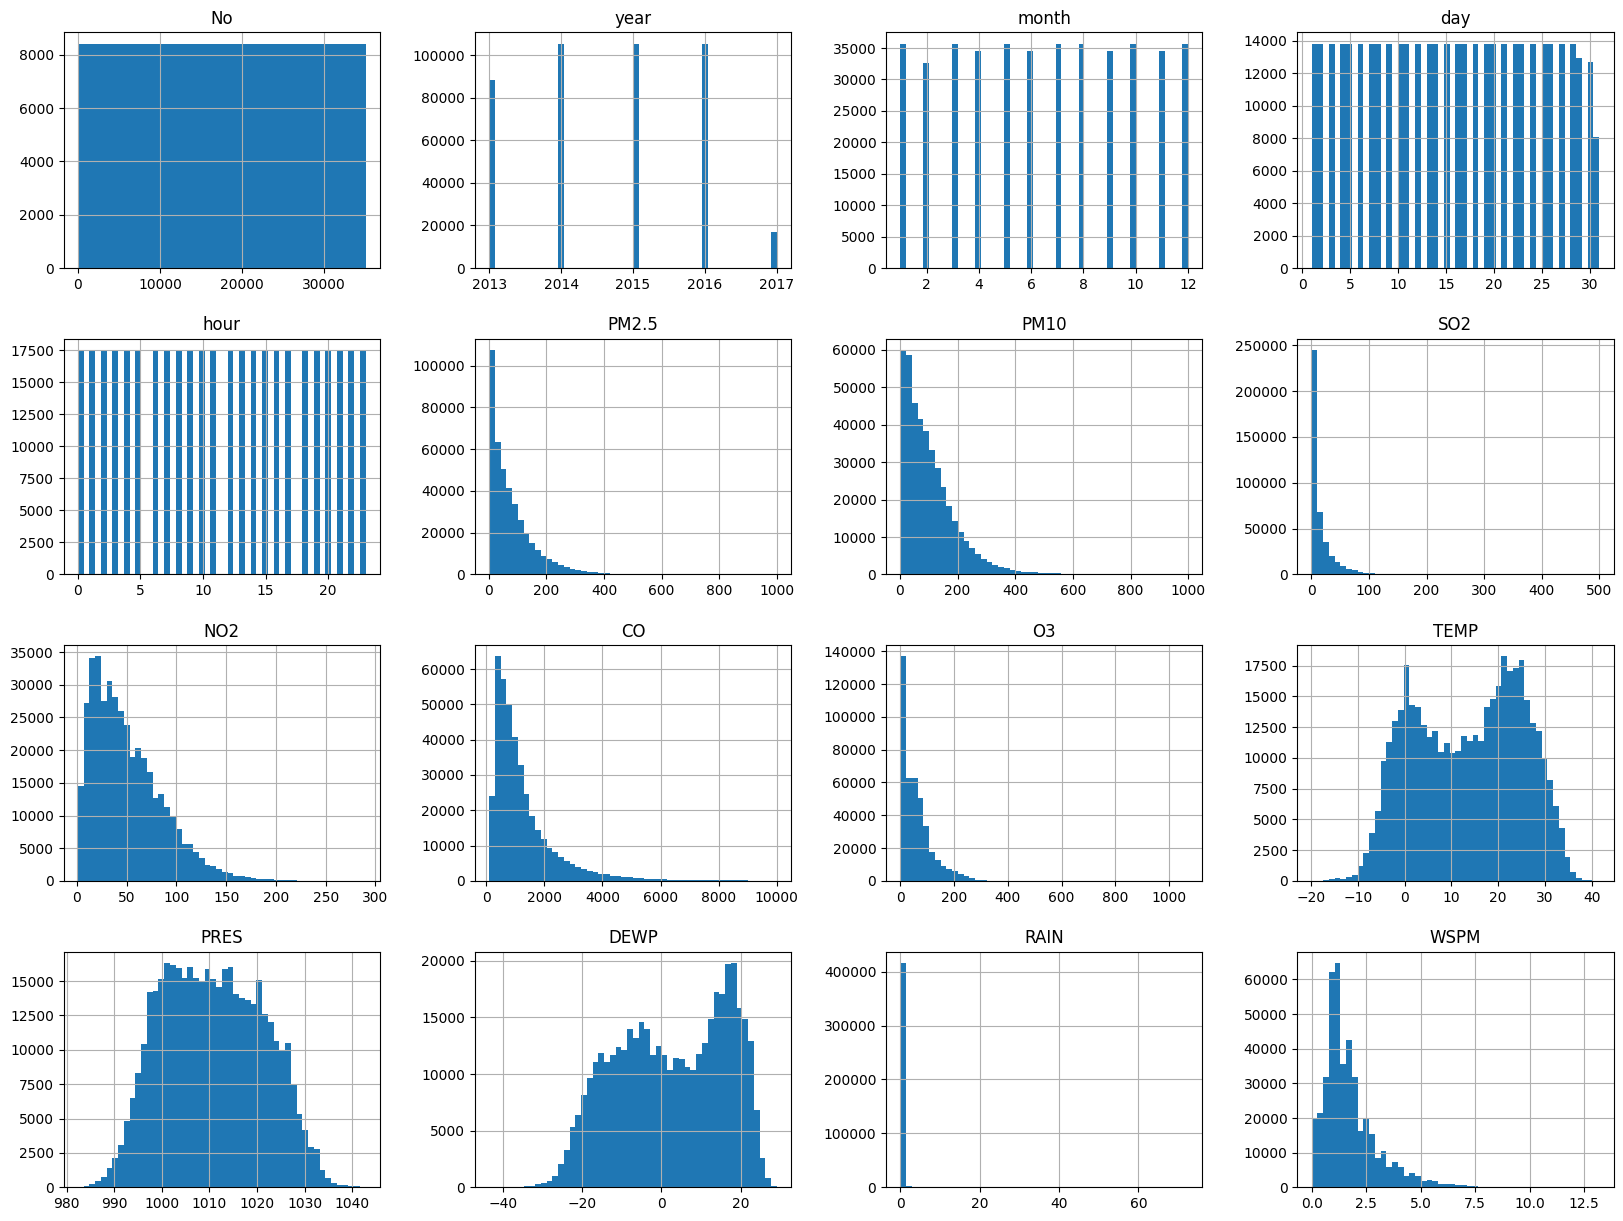

In [8]:
dataframe.hist(bins=50, figsize=(20,15))
plt.show()

## **Data preparation**
Most machine learning algorithms require data to be formatted in a specific way, so datasets generally require some amount of preparation before they can yield useful insights. Some datasets have values that are missing, invalid, or otherwise difficult for an algorithm to process.

### **Missing values**
The dataset contains several missing values as reported by method [**isna**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.isna.html).

In [9]:
dataframe.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


The simplest solution to missing values is to remove the corresponding rows. This can be done by calling the [**dropna**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html) method.

In [10]:
prepared_dataframe = dataframe.copy()
prepared_dataframe = prepared_dataframe.dropna()
prepared_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 382168 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       382168 non-null  int64  
 1   year     382168 non-null  int64  
 2   month    382168 non-null  int64  
 3   day      382168 non-null  int64  
 4   hour     382168 non-null  int64  
 5   PM2.5    382168 non-null  float64
 6   PM10     382168 non-null  float64
 7   SO2      382168 non-null  float64
 8   NO2      382168 non-null  float64
 9   CO       382168 non-null  float64
 10  O3       382168 non-null  float64
 11  TEMP     382168 non-null  float64
 12  PRES     382168 non-null  float64
 13  DEWP     382168 non-null  float64
 14  RAIN     382168 non-null  float64
 15  wd       382168 non-null  object 
 16  WSPM     382168 non-null  float64
 17  station  382168 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 55.4+ MB


### **Encode cyclical data**
Air pollution is strongly related to the time of the day (e.g., 9 A.M. or 10 P.M.) and the time of the year (e.g., January or August).

The following code plots the *hour* column in a graph.

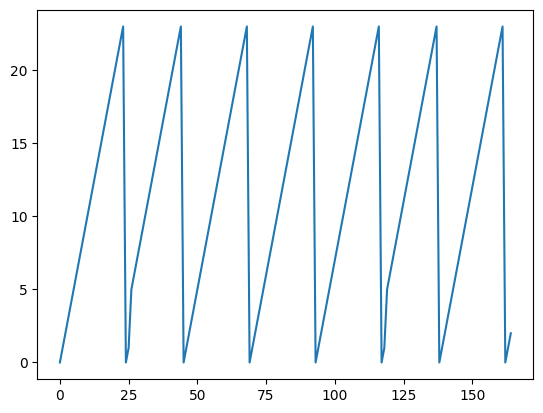

In [11]:
plt.plot(prepared_dataframe['hour'][:165].values)

plt.show()

The graph report the hourly data for a week: a cycle between 0 and 23 that repeats 7 times presenting a **jump discontinuity** at the end of each day, when the hour value goes from  23  to  00.

Presenting cyclical data to a machine learning algorithm is a problem. For instance, it would consider the difference between 23 and 00 greater than that between 22 and 23.

A common method for encoding cyclical data is to transform the data into two dimensions using a sine and cosine transformation.

The hour sine and cosine values are computed and plotted by executing the following code.

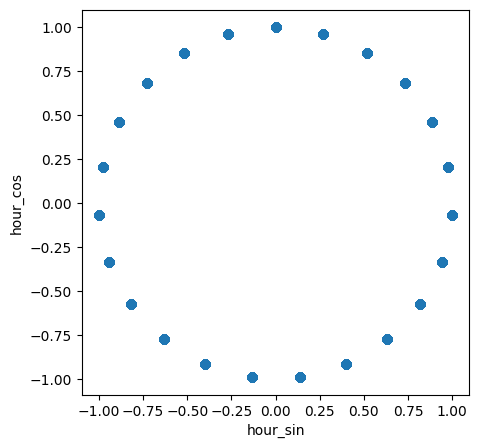

In [12]:
hour_sin = np.sin(2 * np.pi * prepared_dataframe['hour']/23.0)
hour_cos = np.cos(2 * np.pi * prepared_dataframe['hour']/23.0)

plt.figure(figsize=(5, 5))
plt.xlabel('hour_sin')
plt.ylabel('hour_cos')
plt.scatter(hour_sin,hour_cos)

plt.show()

As expected, the hour information are encoded as a cycle.

The following code adds the two new features (*hour_sin* and *hour_cos*) in the **DataFrame** as two new columns.

In [13]:
prepared_dataframe['hour_sin']=hour_sin
prepared_dataframe['hour_cos']=hour_cos

prepared_dataframe.sample(row_count)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,hour_sin,hour_cos
148957,8702,2014,2,26,13,518.0,520.0,171.0,152.0,5700.0,4.0,8.0,1014.7,1.6,0.0,ENE,2.1,Aotizhongxin,-0.398401,-0.917211
129788,24597,2015,12,20,20,277.0,277.0,24.0,117.0,3800.0,2.0,-2.0,1017.2,-4.3,0.0,WNW,0.4,Gucheng,-0.730836,0.682553
137728,32537,2016,11,15,16,43.0,105.0,28.0,58.0,1500.0,27.0,9.6,1015.2,-10.6,0.0,S,2.5,Gucheng,-0.942261,-0.334880
223763,13380,2014,9,9,11,15.0,60.0,9.0,44.0,400.0,73.0,27.4,1004.5,11.8,0.0,W,0.9,Wanliu,0.136167,-0.990686
412426,26723,2016,3,18,10,316.0,316.0,42.0,80.0,2000.0,63.0,14.6,1008.6,1.5,0.0,NE,1.5,Wanshouxigong,0.398401,-0.917211


The same thing can be done with the *month* column by executing the following cell.

In [14]:
month_sin = np.sin(2 * np.pi * prepared_dataframe['month']/12.0)
month_cos = np.cos(2 * np.pi * prepared_dataframe['month']/12.0)

prepared_dataframe['month_sin']=month_sin
prepared_dataframe['month_cos']=month_cos

prepared_dataframe.sample(row_count)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,PRES,DEWP,RAIN,wd,WSPM,station,hour_sin,hour_cos,month_sin,month_cos
113640,8449,2014,2,16,0,459.0,418.0,96.0,161.0,5900.0,...,1018.1,-5.7,0.0,ESE,0.5,Gucheng,0.000000,1.000000,8.660254e-01,5.000000e-01
140739,484,2013,3,21,3,103.0,106.0,7.0,46.0,800.0,...,1008.9,-2.7,0.0,NW,0.5,Aotizhongxin,0.730836,0.682553,1.000000e+00,6.123234e-17
36433,1370,2013,4,27,1,36.0,82.0,28.0,29.0,500.0,...,1000.9,-2.6,0.0,ESE,0.2,Dingling,0.269797,0.962917,8.660254e-01,-5.000000e-01
86036,15909,2014,12,23,20,125.0,210.0,61.0,145.0,3400.0,...,1020.0,-15.9,0.0,NW,2.0,Nongzhanguan,-0.730836,0.682553,-2.449294e-16,1.000000e+00
394421,8718,2014,2,27,5,14.0,5.0,24.0,13.0,400.0,...,1022.3,-12.6,0.0,NW,1.2,Wanshouxigong,0.979084,0.203456,8.660254e-01,5.000000e-01


### **Remove unuseful columns**
The *No*, *month* and *hour* columns contain no useful information. They can be removed from the dataset using the [**drop**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html) method.

In [15]:
prepared_dataframe=prepared_dataframe.drop(['No','month','hour'],axis=1)
prepared_dataframe.sample(row_count)

,year,day,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,hour_sin,hour_cos,month_sin,month_cos
121689,2015,17,27.0,45.0,18.0,64.0,1800.0,7.0,-3.00,1025.0,-16.0,0.0,SSE,0.9,Gucheng,0.631088,-0.775711,5.000000e-01,8.660254e-01
360634,2014,21,18.0,27.0,12.0,59.0,500.0,44.0,21.40,1013.5,-4.7,0.0,NE,2.0,Tiantan,0.398401,-0.917211,8.660254e-01,-5.000000e-01
139071,2017,10,8.0,17.0,3.0,18.0,700.0,52.0,3.89,1018.0,-15.6,0.0,SW,2.7,Gucheng,-0.816970,-0.576680,5.000000e-01,8.660254e-01
16008,2014,28,326.0,360.0,108.0,174.0,5600.0,6.0,-3.70,1026.0,-6.8,0.0,NE,0.7,Guanyuan,0.000000,1.000000,-2.449294e-16,1.000000e+00
395047,2014,25,219.0,240.0,44.0,104.0,1800.0,24.0,10.60,1005.5,4.9,0.0,W,0.6,Wanshouxigong,0.942261,-0.334880,1.000000e+00,6.123234e-17


### **Convert categorical data**
The *wd* and *station* columns are categorical, not numeric. Their conversion into numeric format can be done in two ways:
- *label encoding*, converting each category to a number;
- *one hot encoding*, converting each category value into a new column and assigns a 1 or 0 (True/False) value to the column.

**Label encoding**

First of all, if the column type is *object* and not *category*, the [**astype**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.astype.html) method can be used to convert a column to a category.

In [16]:
label_enc_dataframe=prepared_dataframe.copy()

label_enc_dataframe['wd'] = prepared_dataframe['wd'].astype('category')
label_enc_dataframe['station'] = prepared_dataframe['station'].astype('category')
label_enc_dataframe.dtypes

,0
year,int64
day,int64
PM2.5,float64
PM10,float64
SO2,float64
NO2,float64
CO,float64
O3,float64
TEMP,float64
PRES,float64


Then the encoded values can be assigned to the corresponding column using the **cat.codes** accessor.

In [17]:
label_enc_dataframe['wd'] = label_enc_dataframe['wd'].cat.codes
label_enc_dataframe['station'] = label_enc_dataframe['station'].cat.codes
label_enc_dataframe.sample(row_count)

,year,day,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,hour_sin,hour_cos,month_sin,month_cos
404057,2015,4,73.0,82.0,5.0,26.0,600.0,159.0,16.7,1006.1,1.9,0.0,10,1.5,11,-0.997669,-0.068242,8.660254e-01,-5.000000e-01
8437,2014,15,340.0,319.0,138.0,94.0,3100.0,25.0,4.5,1017.8,-5.6,0.0,1,1.8,4,-0.398401,-0.917211,8.660254e-01,5.000000e-01
385348,2017,14,136.0,151.0,9.0,95.0,2900.0,83.0,-2.4,1031.7,-6.8,0.0,1,0.7,9,0.887885,0.460065,8.660254e-01,5.000000e-01
276805,2016,27,7.0,7.0,3.0,7.0,400.0,60.0,20.1,1018.0,3.9,0.0,4,4.4,8,-0.398401,-0.917211,-1.000000e+00,-1.836970e-16
410006,2015,8,260.0,260.0,23.0,98.0,4200.0,5.0,1.6,1025.3,0.1,0.0,1,1.1,11,-0.631088,-0.775711,-2.449294e-16,1.000000e+00


Label encoding has the advantage that it is straightforward but it has the disadvantage that the numeric values can be “misinterpreted” by the algorithms. For example, the value of 0 is obviously less than the value of 4 but does that really correspond to reality (e.g., *station*)?

**One hot encoding**

Pandas supports this feature using the [**get_dummies**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html) function.

In [18]:
one_hot_enc_dataframe=pd.get_dummies(prepared_dataframe, columns=['wd', 'station'], prefix=['wd', 'station'],dtype=float)
one_hot_enc_dataframe.sample(row_count)

,year,day,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,...,station_Dingling,station_Dongsi,station_Guanyuan,station_Gucheng,station_Huairou,station_Nongzhanguan,station_Shunyi,station_Tiantan,station_Wanliu,station_Wanshouxigong
104775,2017,11,10.0,29.0,4.0,11.0,200.0,75.0,9.2,1021.7,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
313855,2016,19,101.0,105.0,3.0,34.0,1800.0,4.0,-5.8,1015.7,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
329326,2014,24,48.0,66.0,2.0,41.0,800.0,42.0,17.4,1008.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
323167,2014,11,73.0,77.0,78.0,62.0,2800.0,4.0,-8.8,1022.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
373328,2015,2,26.0,61.0,2.0,53.0,800.0,2.0,16.3,1007.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


One hot encoding has the benefit of not weighting a value improperly but does have the downside of adding more columns to the data set (it depends by the number of categories in a column).

**What is the best solution?**

It depends on the specific dataset used.

In this tutorial, because both *wd* and *station* columns contain categorical values without any numerical relation, it is better to use the *one hot encoding* solution.

In [19]:
#used_dataframe=label_enc_dataframe
used_dataframe=one_hot_enc_dataframe

## **Split features from target values**

The following code separates the target values (the concentration of air pollutants) from the features.

In [20]:
target_data=['PM2.5','PM10','SO2','NO2','CO','O3']

dataframe_x=used_dataframe.drop(target_data, axis=1)
dataframe_y=used_dataframe[target_data]

Some randomly selected feature rows can be shown by executing the following code.

In [21]:
dataframe_x.sample(row_count)

,year,day,TEMP,PRES,DEWP,RAIN,WSPM,hour_sin,hour_cos,month_sin,...,station_Dingling,station_Dongsi,station_Guanyuan,station_Gucheng,station_Huairou,station_Nongzhanguan,station_Shunyi,station_Tiantan,station_Wanliu,station_Wanshouxigong
116587,2014,18,26.2,994.4,19.1,0.0,1.0,-0.887885,0.460065,1.224647e-16,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
94637,2015,17,-6.7,1029.5,-15.7,0.0,1.1,0.979084,0.203456,-2.449294e-16,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
355569,2013,22,20.5,1012.3,17.9,0.0,1.8,0.631088,-0.775711,-1.000000e+00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
172737,2016,13,7.7,1015.2,3.5,0.0,0.2,0.631088,-0.775711,-5.000000e-01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20191,2015,20,20.5,1009.1,13.5,0.0,1.5,0.942261,-0.334880,1.224647e-16,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Some randomly selected target rows can be shown by executing the following code.

In [22]:
dataframe_y.sample(row_count)

,PM2.5,PM10,SO2,NO2,CO,O3
219112,15.0,19.0,14.0,54.0,400.0,57.0
197133,17.0,36.0,2.0,53.0,700.0,50.0
142106,85.0,106.0,24.0,40.0,1899.0,73.0
210934,11.0,6.0,10.0,38.0,400.0,66.0
390864,31.0,4.0,1.0,56.0,700.0,4.0


The Numpy representation of the **DataFrame** can be obtained using the [**to_numpy**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_numpy.html#pandas.DataFrame.to_numpy) method.

In [23]:
x=dataframe_x.to_numpy()
y=dataframe_y.to_numpy()

print('Feature shape: ',x.shape)
print('Target shape: ',y.shape)

Feature shape:  (382168, 39)
Target shape:  (382168, 6)


## **Split data into training and test sets**
To evaluate the generalization capabilites of the regression model, it is necessary to have a separate dataset (called test set) to use in the final evaluation of our model after the training process.

For this reason, *x* is divided into two subsets: training and test sets.

**Scikit-learn** library provides the function [**train_test_split**](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to separate a dataset into two parts.

The *test_size* parameter represents the percentage (or the absolute number) of patterns to include in the test set.

The *shuffle* parameter is used to mix patterns before splitting.

In [24]:
test_size=0.25

train_x, test_x, train_y, test_y = train_test_split(x, y, test_size = test_size,random_state = 1,shuffle=True)

print('Train feature shape: ',train_x.shape)
print('Train target shape: ',train_y.shape)
print('Test feature shape: ',test_x.shape)
print('Test target shape: ',test_y.shape)

Train feature shape:  (286626, 39)
Train target shape:  (286626, 6)
Test feature shape:  (95542, 39)
Test target shape:  (95542, 6)


# **Linear regression**
As a starting point, we will evaluate the performance of the least squares linear regression using the class [**LinearRegression**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) provided by Scikit-learn.

The [**fit**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.fit) method fits a linear model to minimize the residual sum of squares between the target values, and the values predicted by the linear approximation.

In [25]:
linear_model = LinearRegression().fit(train_x, train_y)

## **Performance evaluation**
The following code calls the [**predict**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.predict) method to generate the predictions (*train_y_pred* and *test_y_pred*) of the training and test sets (*train_x* and *test_x*).

In [26]:
train_y_pred=linear_model.predict(train_x)
test_y_pred=linear_model.predict(test_x)

print('Train predictions shape: ',train_y_pred.shape)
print('Test predictions shape: ',test_y_pred.shape)

Train predictions shape:  (286626, 6)
Test predictions shape:  (95542, 6)


### **RMSE**
The regression accuracy can be measured using the RMSE.

Scikit-learn library provides the function [**root_mean_squared_error**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html) to compute RMSE metric.

In [27]:
rmse_train = root_mean_squared_error(train_y,train_y_pred)
rmse_test = root_mean_squared_error(test_y,test_y_pred)

print('RMSE - Train: {:.3f} Test: {:.3f}'.format(rmse_train,rmse_test))

RMSE - Train: 187.396 Test: 188.440


### **True vs predicted values and error distributions**
To better analyze the model performance on the test set, it is useful to plot the predicted and the true values and to visualize the error distribution.

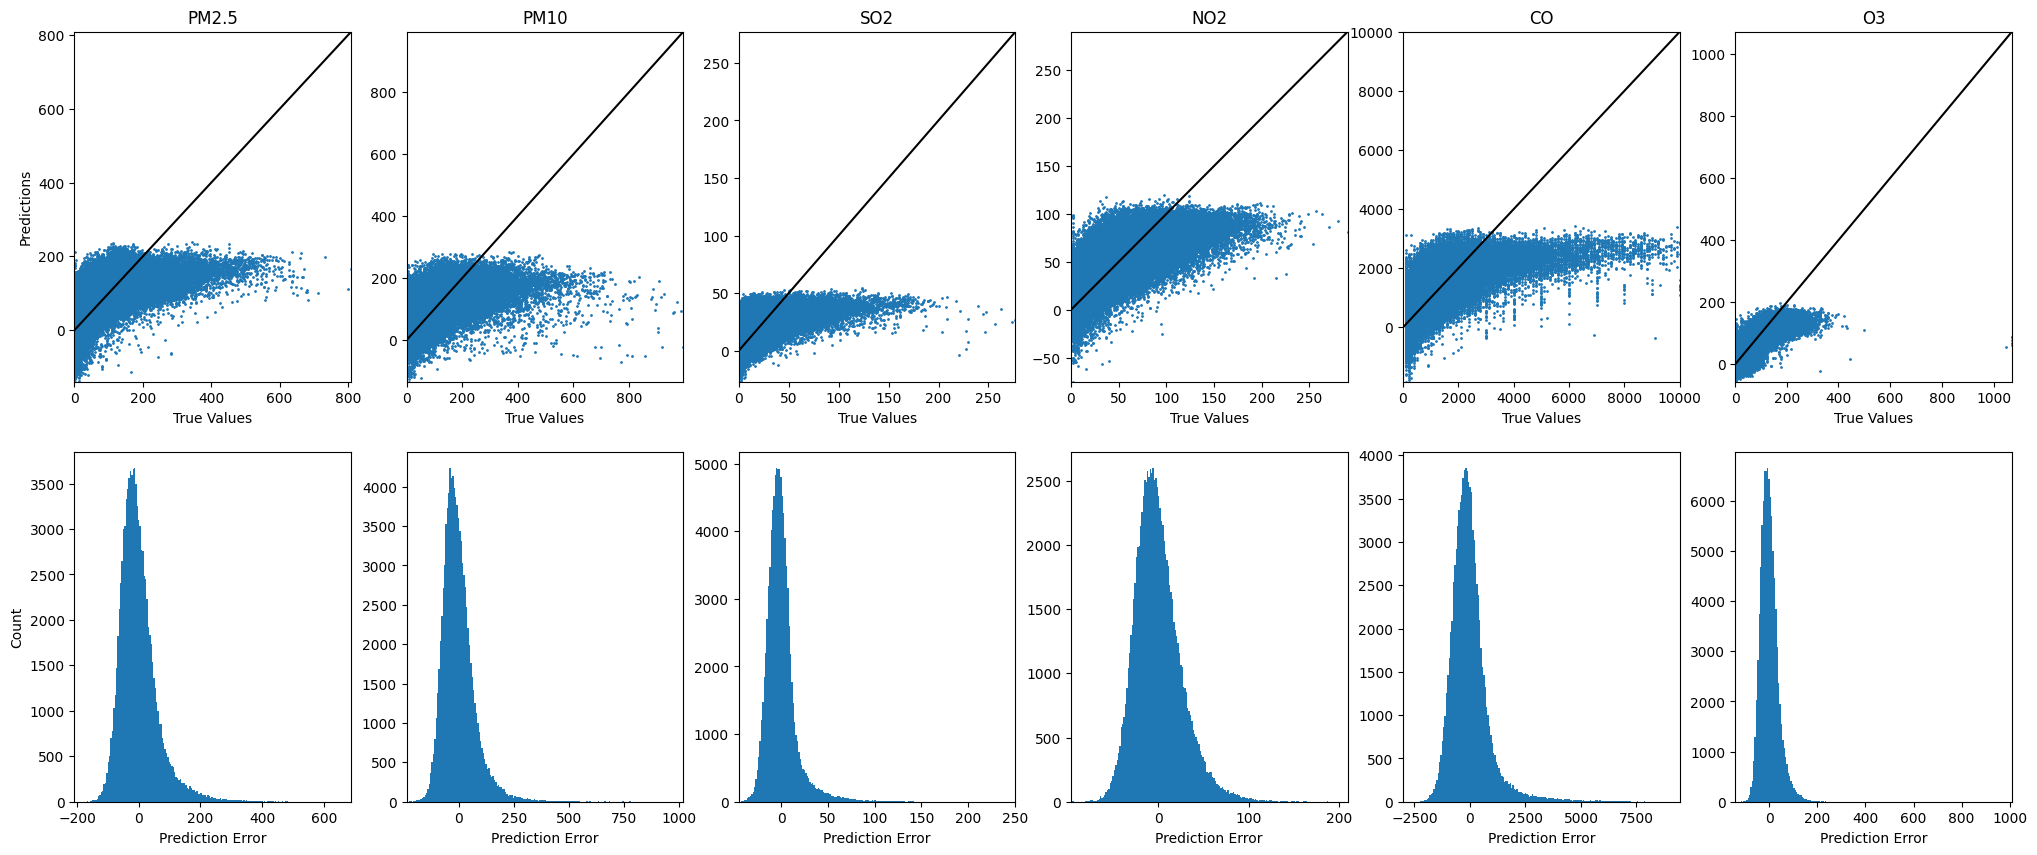

In [28]:
plot_prediction_results(test_y, test_y_pred, target_data, 200)

### **Best and worst predictions**
To select best and worst predictions the RMSE value for each test instance is computed.

In [29]:
rmse_test_instances=root_mean_squared_error(test_y.transpose(),test_y_pred.transpose(),multioutput='raw_values')

rmse_test_instances_sorted_indices=np.argsort(rmse_test_instances)

The following code shows the best predictions returned by the model.

The following code shows the worst predictions of the model.

In [30]:
with np.printoptions(precision=1, suppress=True):
  print('Worst RMSE:')
  print(rmse_test_instances[rmse_test_instances_sorted_indices[-row_count:]])

  print('True values:')
  print(test_y[rmse_test_instances_sorted_indices[-row_count:]])

  print('Predicted values:')
  print(test_y_pred[rmse_test_instances_sorted_indices[-row_count:]])

Worst RMSE:
[3527.8 3554.1 3566.2 3640.4 3858.2]
True values:
[[   40.    40.     4.    43. 10000.    35.]
 [   42.    42.     3.    50. 10000.    28.]
 [   71.    71.     7.    49. 10000.    80.]
 [   68.    84.     7.    46. 10000.    86.]
 [   10.    10.     2.     2.  9100.     6.]]
Predicted values:
[[  78.5  100.5   11.4   55.3 1359.1   51.8]
 [  74.1   98.2    8.    54.5 1294.5   44.9]
 [  83.   109.3    9.8   63.5 1264.8   73.2]
 [  79.9  104.9    9.8   43.9 1082.9  113. ]
 [ -78.2  -66.6  -12.1   -4.1 -349.6   66.5]]


# **Linear neural network**
Before building a DNN model, we start with a simple neural network to apply a linear transformation:

$\boldsymbol{\rm{y=Wx+b}}$

## **Model definition**
Training a model with Keras starts by defining the model architecture.

The following function creates a simple linear neural network given:
- the number of input features (*input_count*);
- the number of output targets (*output_count*).

In Keras, a sequential is a stack of layers where each layer has exactly one input and one output. It can be created by passing a list of layers to the  constructor [**keras.Sequential**](https://keras.io/guides/sequential_model/).

[**Keras layers API**](https://keras.io/api/layers/) offers a wide range of built-in layers ready for use, including:
- [**Input**](https://keras.io/api/layers/core_layers/input/) - the input of the model. Note that, the **Input** is optional: in that case the model does not have any weights until the first call to a training/evaluation method (since it is not yet built);
- [**Dense**](https://keras.io/api/layers/core_layers/dense/) - a fully-connected layer.

In [31]:
def build_linear_nn(input_count,output_count):
	model = keras.Sequential(
        [
          layers.Input(shape=(input_count,)),
          layers.Dense(output_count)
        ]
      )

	return model

## **Model creation**
The following code creates a linear neural network by calling the **build_linear_nn** function defined above.

In [32]:
linear_nn=build_linear_nn(train_x.shape[1],train_y.shape[1])

## **Model visualization**
A string summary of the network can be printed using the [**summary**](https://keras.io/api/models/model/#summary-method) method.

In [33]:
linear_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │           240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240 (960.00 B)

 Trainable params: 240 (960.00 B)

 Non-trainable params: 0 (0.00 B)

The summary is useful for simple models, but can be confusing for complex models.

Function [**keras.utils.plot_model**](https://keras.io/api/utils/model_plotting_utils/) creates a plot of the neural network graph that can make more complex models easier to understand.

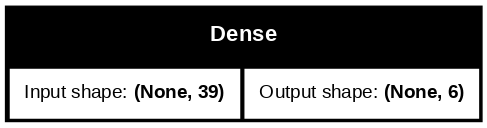

In [34]:
keras.utils.plot_model(linear_nn,show_shapes=True, show_layer_names=False,dpi=100)

## **Model compilation**
The compilation is the final step in configuring the model for training.

The following code use the [**compile**](https://keras.io/api/models/model_training_apis/#compile-method) method to compile the model.
The important arguments are:
- the optimization algorithm (*optimizer*);
- the loss function (*loss*);
- the metrics used to evaluate the performance of the model (*metrics*).

The most common [optimization algorithms](https://keras.io/api/optimizers/#available-optimizers), [loss functions](https://keras.io/api/losses/#available-losses) and [metrics](https://keras.io/api/metrics/#available-metrics) are already available in Keras. You can either pass them to **compile** as an instance or by the corresponding string identifier. In the latter case, the default parameters will be used.

In [35]:
linear_nn.compile(loss='mse', optimizer='SGD',metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])

## **Split data into training and validation sets**
In order to avoid overfitting during training, it is necessary to have a separate dataset (called validation set), in addition to the training and test datasets, to choose the optimal value for the hyperparameters.

![alt text](https://biolab.csr.unibo.it/ferrara/Courses/DL/Tutorials/Regression/TrainValTestSets.png)

For this reason, *train_x* and *train_y* are divided into training and validation sets using the **train_test_split** function provided by Scikit-learn.

The *val_size* variable represents the percentage (or the absolute number) of patterns to include in the validation set.

In [36]:
val_size=0.25

train_x, val_x, train_y, val_y = train_test_split(train_x, train_y, test_size = val_size,random_state = 1,shuffle=True)

print('Train feature shape: ',train_x.shape)
print('Train target shape: ',train_y.shape)
print('Validation feature shape: ',val_x.shape)
print('Validation target shape: ',val_y.shape)

Train feature shape:  (214969, 39)
Train target shape:  (214969, 6)
Validation feature shape:  (71657, 39)
Validation target shape:  (71657, 6)


## **Training**
Now we are ready to train our model by calling the [**fit**](https://keras.io/api/models/model_training_apis/#fit-method) method.

It trains the model for a fixed number of epochs (*epoch_count*) using the training set (*train_x* and *train_y*) divided into mini-batches of *batch_size* elements. During the training process, the performances will be evaluated on both training and validation (*train_x* and *val_x*) sets.

In [37]:
epoch_count = 2
batch_size = 512

history = linear_nn.fit(train_x, train_y,validation_data=(val_x,val_y), epochs=epoch_count, batch_size=batch_size,shuffle = True)

Epoch 1/2
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - rmse: nan - val_loss: nan - val_rmse: nan
Epoch 2/2
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: nan - rmse: nan - val_loss: nan - val_rmse: nan


The neural network does not converge. This is because the features present values in very different ranges (as shown in the table of statistics).

This happens because the features are multiplied by the model weights. So the scale of the outputs and the scale of the gradients are affected by the scale of the inputs.

Although a model might converge without feature normalization, normalization makes training much more stable.

### **Data normalization**
It is good practice to normalize features that use different scales and ranges.

Scikit-learn library provides the class [**StandardScaler**](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) to normalize features by removing the mean and scaling to unit variance.

In [38]:
scaler = StandardScaler().fit(train_x)
train_x = scaler.transform(train_x)
val_x=scaler.transform(val_x)
test_x = scaler.transform(test_x)

Once normalized the features, the training process can be launched again.

<u>Note that, it is necessary to create and compile a new model before executing the training process, otherwise it will be performed on a model already trained.</u>

In [39]:
epoch_count = 10
batch_size = 512

linear_nn=build_linear_nn(train_x.shape[1],train_y.shape[1])

linear_nn.compile(loss='mse', optimizer='SGD',metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])

history = linear_nn.fit(train_x, train_y,validation_data=(val_x,val_y), epochs=epoch_count, batch_size=batch_size,shuffle = True)

Epoch 1/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 269505.4062 - rmse: 519.1391 - val_loss: 188268.0312 - val_rmse: 433.8987
Epoch 2/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 168667.3281 - rmse: 410.6913 - val_loss: 163772.8125 - val_rmse: 404.6885
Epoch 3/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 156510.3281 - rmse: 395.6139 - val_loss: 156885.7812 - val_rmse: 396.0881
Epoch 4/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 151306.8281 - rmse: 388.9818 - val_loss: 152655.6875 - val_rmse: 390.7118
Epoch 5/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 147771.4688 - rmse: 384.4106 - val_loss: 149644.9219 - val_rmse: 386.8397
Epoch 6/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 145203.2188 - rmse: 381.0554 - val_loss: 147452.0000 - val_rmse: 383.9948
Epoch 7/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 143311.8906 - rmse: 378.5656 - val_loss: 145832.3594 - val_rmse: 381.8800
Epoch 8/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 14

### **Visualize the training process**
We can learn a lot about our model by observing the graph of its performance over time during training.

The **fit** method returns an object (*history*) containing loss and metrics values at successive epochs for both training and validation sets.

The following code calls the **plot_history** function defined above to draw in a graph the loss and RMSE trend over epochs on both training and validation sets.

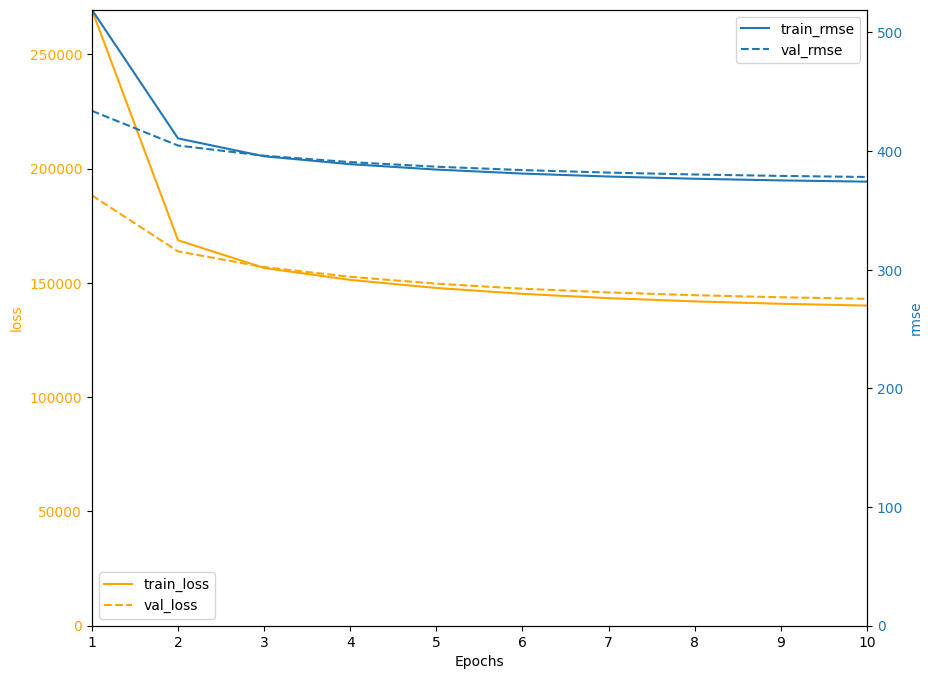

In [40]:
plot_history(history,'rmse')

## **Performance evaluation**
The following code calls the [**predict**](https://keras.io/api/models/model_training_apis/#predict-method) method to generate the predictions (*train_y_pred*, *val_y_pred* and *test_y_pred*) of the training, validation and test sets (*train_x*, *val_x* and *test_x*).

In [41]:
train_y_pred=linear_nn.predict(train_x)
val_y_pred=linear_nn.predict(val_x)
test_y_pred=linear_nn.predict(test_x)

print('Train predictions shape: ',train_y_pred.shape)
print('Validation predictions shape: ',val_y_pred.shape)
print('Test predictions shape: ',test_y_pred.shape)

6718/6718 ━━━━━━━━━━━━━━━━━━━━ 4s 622us/step
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 1s 632us/step
2986/2986 ━━━━━━━━━━━━━━━━━━━━ 2s 766us/step
Train predictions shape:  (214969, 6)
Validation predictions shape:  (71657, 6)
Test predictions shape:  (95542, 6)


### **RMSE**
The regression accuracy can be measured using the RMSE.

In [42]:
rmse_train = root_mean_squared_error(train_y,train_y_pred)
rmse_val = root_mean_squared_error(val_y,val_y_pred)
rmse_test = root_mean_squared_error(test_y,test_y_pred)

print('RMSE - Train: {:.3f} Val: {:.3f} Test: {:.3f}'.format(rmse_train,rmse_val,rmse_test))

RMSE - Train: 188.328 Val: 190.465 Test: 189.814


### **True vs predicted values and error distributions**
To better analyze the model performance on the test set, it is useful to plot the predicted and the true values and to visualize the error distribution.

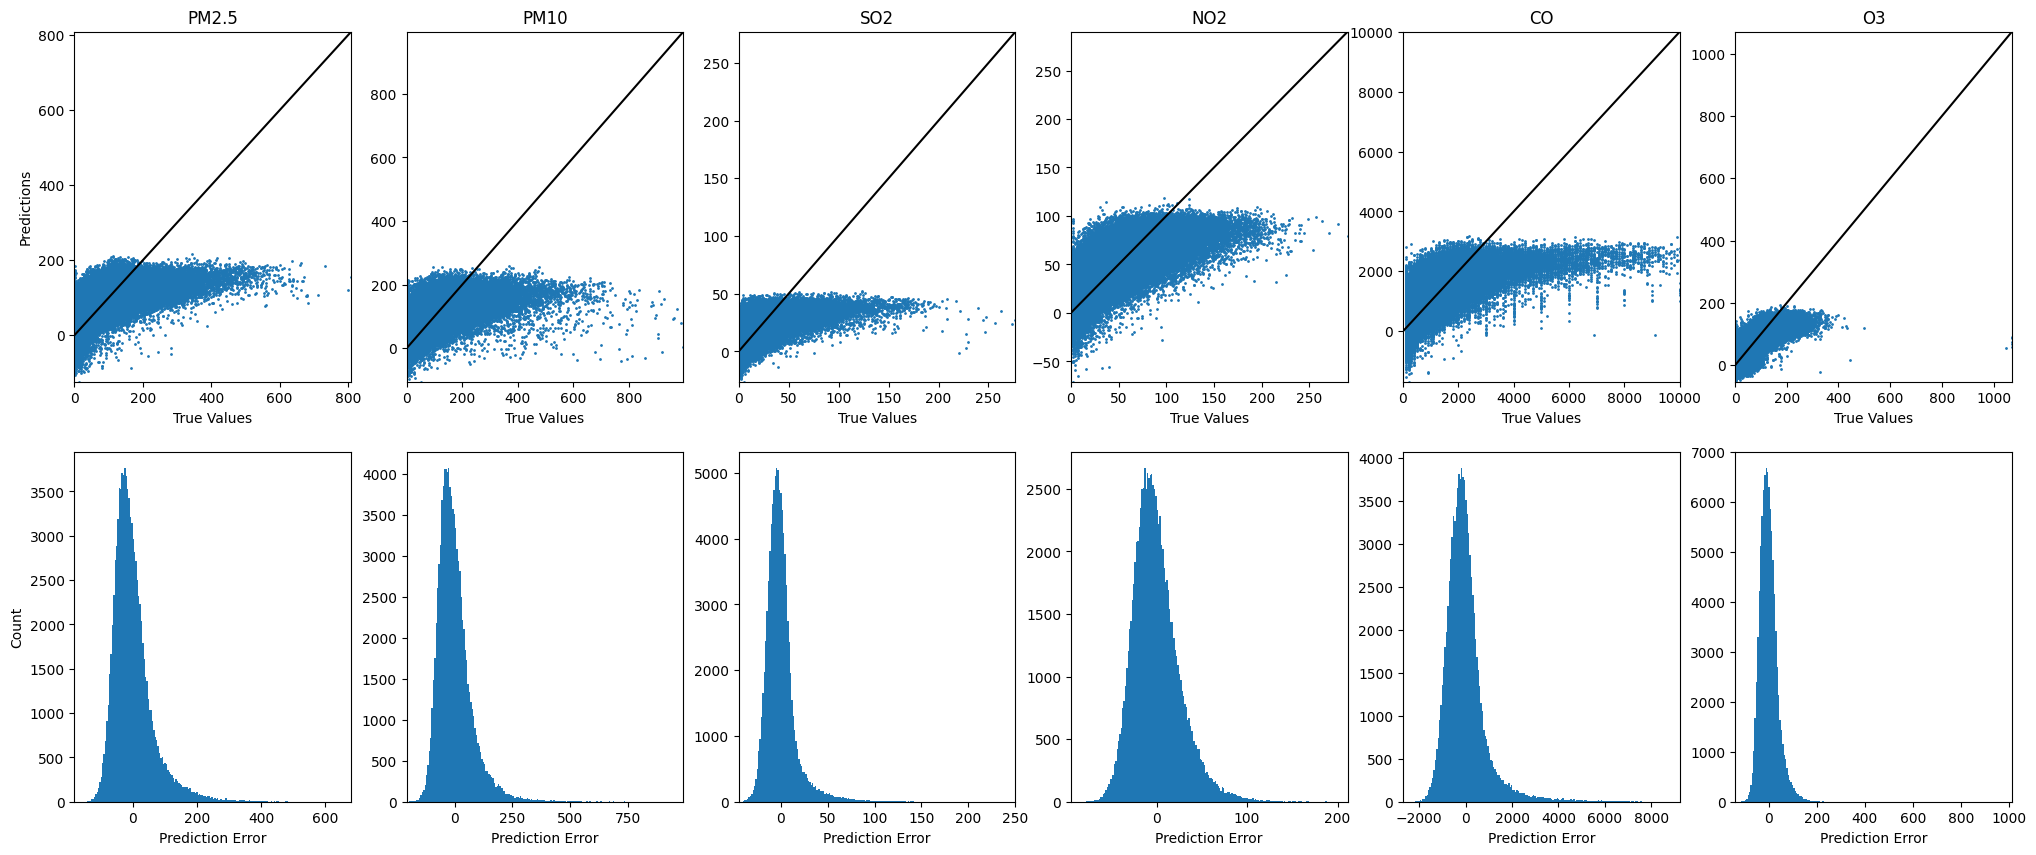

In [43]:
plot_prediction_results(test_y,test_y_pred,target_data,200)

### **Best and worst predictions**
To select best and worst predictions the RMSE value for each test instance is computed.

In [44]:
rmse_test_instances=root_mean_squared_error(test_y.transpose(),test_y_pred.transpose(),multioutput='raw_values')

rmse_test_instances_sorted_indices=np.argsort(rmse_test_instances)

The following code shows the best predictions returned by the model.

In [45]:
with np.printoptions(precision=1, suppress=True):
  print('RMSE:')
  print(rmse_test_instances[rmse_test_instances_sorted_indices[:row_count]])

  print('True values:')
  print(test_y[rmse_test_instances_sorted_indices[:row_count]])

  print('Predicted values:')
  print(test_y_pred[rmse_test_instances_sorted_indices[:row_count]])

RMSE:
[3.1 3.7 4.2 4.3 4.6]
True values:
[[   9.   33.    2.   34.  600.   31.]
 [  53.   59.    2.   22.  900.   21.]
 [   8.   55.    6.   20.  300.   65.]
 [  88.  116.   36.   71. 1700.    2.]
 [   9.   25.   11.   18.  400.   58.]]
Predicted values:
[[   7.9   32.2    1.6   33.7  606.6   34.5]
 [  50.3   56.5    6.2   27.8  903.6   19.5]
 [   8.5   49.     9.6   25.5  296.6   68.5]
 [  94.9  110.8   31.5   72.2 1699.2   -1.8]
 [   0.8   25.7   16.2   20.7  395.2   59.4]]


The following code shows the worst predictions of the model.

In [46]:
with np.printoptions(precision=1, suppress=True):
  print('RMSE:')
  print(rmse_test_instances[rmse_test_instances_sorted_indices[-row_count:]])

  print('True values:')
  print(test_y[rmse_test_instances_sorted_indices[-row_count:]])

  print('Predicted values:')
  print(test_y_pred[rmse_test_instances_sorted_indices[-row_count:]])

RMSE:
[3532.  3558.1 3588.2 3675.  3769.1]
True values:
[[   35.    35.     2.    60. 10000.     6.]
 [   42.    42.     3.    50. 10000.    28.]
 [   71.    71.     7.    49. 10000.    80.]
 [   68.    84.     7.    46. 10000.    86.]
 [   10.    10.     2.     2.  9100.     6.]]
Predicted values:
[[  96.8  121.2    6.5   53.8 1349.3   76.6]
 [  82.7  110.3    9.8   56.2 1284.8   50.3]
 [  87.1  117.5   11.3   64.4 1210.9   78.9]
 [  82.7  113.1   11.4   44.5  998.2  120.4]
 [ -51.6  -35.5   -7.9    3.2 -131.8   69.2]]


# **Deep neural network**
The previous section implemented a simple linear neural network.

This section implements a DNN model. The code is basically the same except the model is expanded to include some *hidden* non-linear layers. The nonlinearity is introduced using the *ReLU* activation function.

## **Model definition**
The following function creates a DNN model given:
- the number of input features (*input_count*);
- the number of output targets (*output_count*);
- the number of neurons for each hidden layer (*neuron_count_per_hidden_layer*);
- the string identifier of the activation function of the hidden layers (*activation*).

In [ ]:
def build_dnn(input_count,output_count,neuron_count_per_hidden_layer=[128,128],activation='relu'):
  model = keras.Sequential()
  model.add(layers.Input(shape=(input_count,)))

  for n in neuron_count_per_hidden_layer:
    model.add(layers.Dense(n, activation=activation))

  model.add(layers.Dense(output_count))

  return model

## **Model creation**
The following code creates a DNN model by calling the **build_dnn** function defined above.

In [ ]:
dnn=build_dnn(train_x.shape[1],train_y.shape[1])

## **Model visualization**
A string summary of the network can be printed by executing the following code.

In [ ]:
dnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,406 (87.52 KB)

 Trainable params: 22,406 (87.52 KB)

 Non-trainable params: 0 (0.00 B)

Alternatively, a plot of the neural network graph can be visualized.

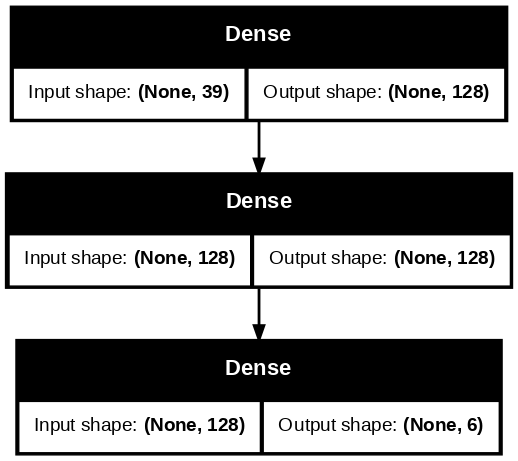

In [ ]:
keras.utils.plot_model(dnn,show_shapes=True, show_layer_names=False,dpi=100)

## **Model compilation**
The following code compiles the model as already done for the linear neural network.

In [ ]:
dnn.compile(loss='mse', optimizer='SGD',metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])

## **Training**
Now we are ready to train our model by calling the **fit** method.

In [ ]:
epoch_count = 2
batch_size = 512

history = dnn.fit(train_x, train_y,validation_data=(val_x,val_y), epochs=epoch_count, batch_size=batch_size,shuffle = True)

Epoch 1/2
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: nan - rmse: nan - val_loss: nan - val_rmse: nan
Epoch 2/2
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: nan - rmse: nan - val_loss: nan - val_rmse: nan


The neural network does not converge. This is because the learning rate is too high.

The learning rate needs to be reduced before the training process can be launched again.

<u>Note that, it is necessary to create and compile a new model before executing the training process, otherwise it will be performed on a model already trained.</u>

In [ ]:
epoch_count = 5
batch_size = 512
learning_rate=0.0001

dnn=build_dnn(train_x.shape[1],train_y.shape[1])

optimizer=keras.optimizers.SGD(learning_rate=learning_rate)
dnn.compile(loss='mse', optimizer=optimizer,metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])

history = dnn.fit(train_x, train_y,validation_data=(val_x,val_y), epochs=epoch_count, batch_size=batch_size,shuffle = True)

Epoch 1/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 131548.1250 - rmse: 362.6956 - val_loss: 107582.2266 - val_rmse: 327.9973
Epoch 2/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 102099.4219 - rmse: 319.5300 - val_loss: 104682.8672 - val_rmse: 323.5473
Epoch 3/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 96985.0312 - rmse: 311.4242 - val_loss: 93942.6328 - val_rmse: 306.5006
Epoch 4/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 94694.3828 - rmse: 307.7245 - val_loss: 94119.2500 - val_rmse: 306.7886
Epoch 5/5
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 92813.1797 - rmse: 304.6526 - val_loss: 89979.2188 - val_rmse: 299.9654


### **Visualize the training process**
The following code calls the **plot_history** function defined above to draw in a graph the loss and RMSE trend over epochs on both training and validation sets.

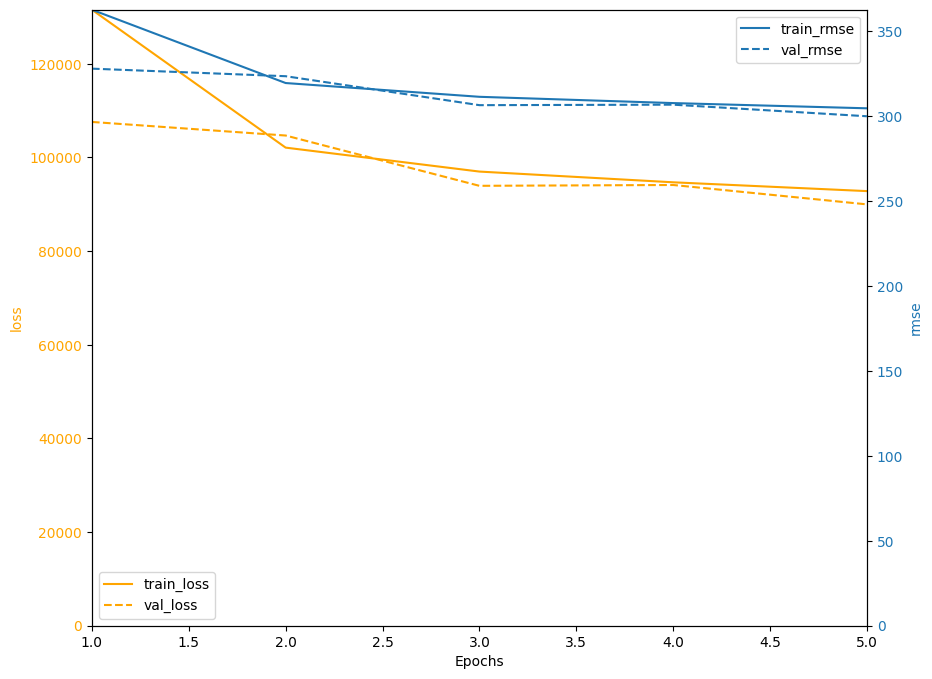

In [ ]:
plot_history(history,'rmse')

### **Stop the training process in advance**
Break training when a metric or the loss has stopped improving on the validation set, helps to avoid overfitting.

For this purpose, Keras provides a class called [**EarlyStopping**](https://keras.io/api/callbacks/early_stopping/). Important class parameters are:
- *monitor* - the name of the metric or the loss to be observed;
- *patience* - the number of epochs with no improvement after which training will be stopped;
- *restore_best_weights* - whether to restore model weights from the epoch with the best value of the monitored quantity.

Once created an instance of the **EarlyStopping** class, it can be passed to the **fit** method in the *callbacks* parameter.

<u>Note that, it is necessary to create and compile a new model before executing the training process, otherwise it will be performed on a model already trained.</u>

In [ ]:
epoch_count = 100
batch_size = 512
learning_rate=0.0001
patience=5

dnn=build_dnn(train_x.shape[1],train_y.shape[1])

optimizer=keras.optimizers.SGD(learning_rate=learning_rate)
dnn.compile(loss='mse', optimizer=optimizer,metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

history = dnn.fit(train_x, train_y,validation_data=(val_x,val_y), epochs=epoch_count, batch_size=batch_size, shuffle = True, callbacks=[early_stop])

Epoch 1/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 132096.9531 - rmse: 363.4514 - val_loss: 102223.1328 - val_rmse: 319.7235
Epoch 2/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 102450.9688 - rmse: 320.0796 - val_loss: 96484.1797 - val_rmse: 310.6190
Epoch 3/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 97625.5938 - rmse: 312.4510 - val_loss: 97832.8750 - val_rmse: 312.7825
Epoch 4/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 94664.0469 - rmse: 307.6752 - val_loss: 118762.4297 - val_rmse: 344.6193
Epoch 5/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 93098.7656 - rmse: 305.1209 - val_loss: 96194.4766 - val_rmse: 310.1523
Epoch 6/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 90905.5781 - rmse: 301.5055 - val_loss: 92781.9219 - val_rmse: 304.6013
Epoch 7/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 89893.1094 - rmse: 299.8218 - val_loss: 99622.3828 - val_rmse: 315.6301
Epoch 8/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8879

#### **Visualize the training process**
The following code calls the **plot_history** function defined above to draw in a graph the loss and RMSE trend over epochs on both training and validation sets.

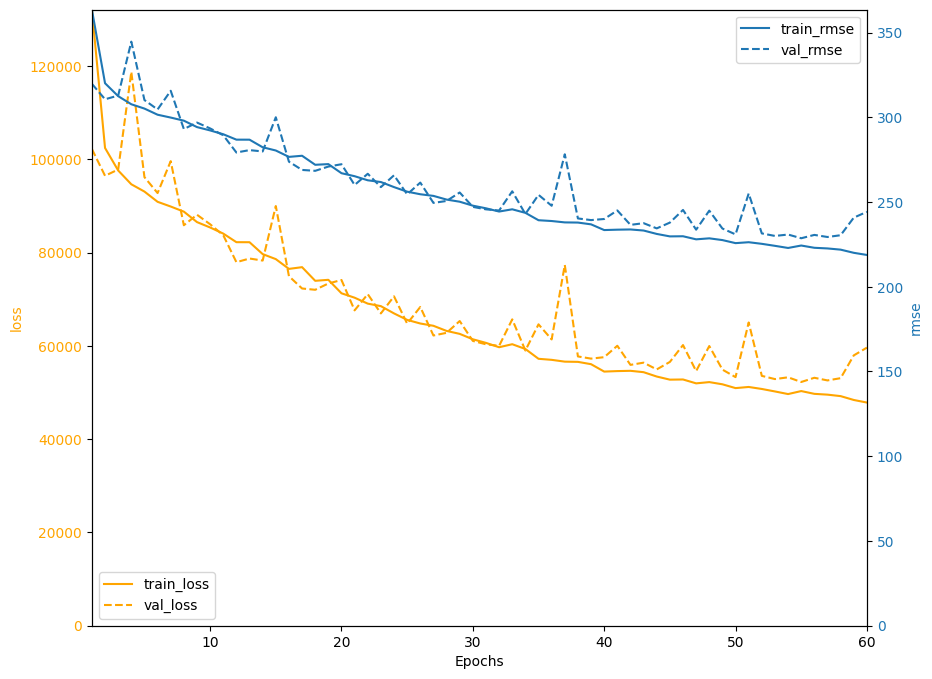

In [ ]:
plot_history(history,'rmse')

## **Performance evaluation on training and validation sets**
The following code calls the **predict** method to generate the predictions (*train_y_pred* and *val_y_pred*) of the training and validation sets (*train_x* and *val_x*).

In [ ]:
train_y_pred=dnn.predict(train_x)
val_y_pred=dnn.predict(val_x)

print('Train predictions shape: ',train_y_pred.shape)
print('Validation predictions shape: ',val_y_pred.shape)

6718/6718 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Train predictions shape:  (214969, 6)
Validation predictions shape:  (71657, 6)


### **RMSE**
The regression accuracy can be measured using the RMSE.

In [ ]:
rmse_train = root_mean_squared_error(train_y,train_y_pred)
rmse_val = root_mean_squared_error(val_y,val_y_pred)

print('RMSE - Train: {:.3f} Val: {:.3f}'.format(rmse_train,rmse_val))

RMSE - Train: 112.533 Val: 120.236


## **Performance evaluation on the test set**
The following code calls the **predict** method to generate the predictions (*test_y_pred*) of the test set (*test_x*) and compute the regression accuracy using the RMSE.

In [ ]:
test_y_pred=dnn.predict(test_x)

print('Test predictions shape: ',test_y_pred.shape)

rmse_test = root_mean_squared_error(test_y,test_y_pred)

print('RMSE - Test: {:.3f}'.format(rmse_test))

NameError: name 'dnn' is not defined

### **True vs predicted values and error distributions**
To better analyze the model performance on the test set, it is useful to plot the predicted and the true values and to visualize the error distribution.

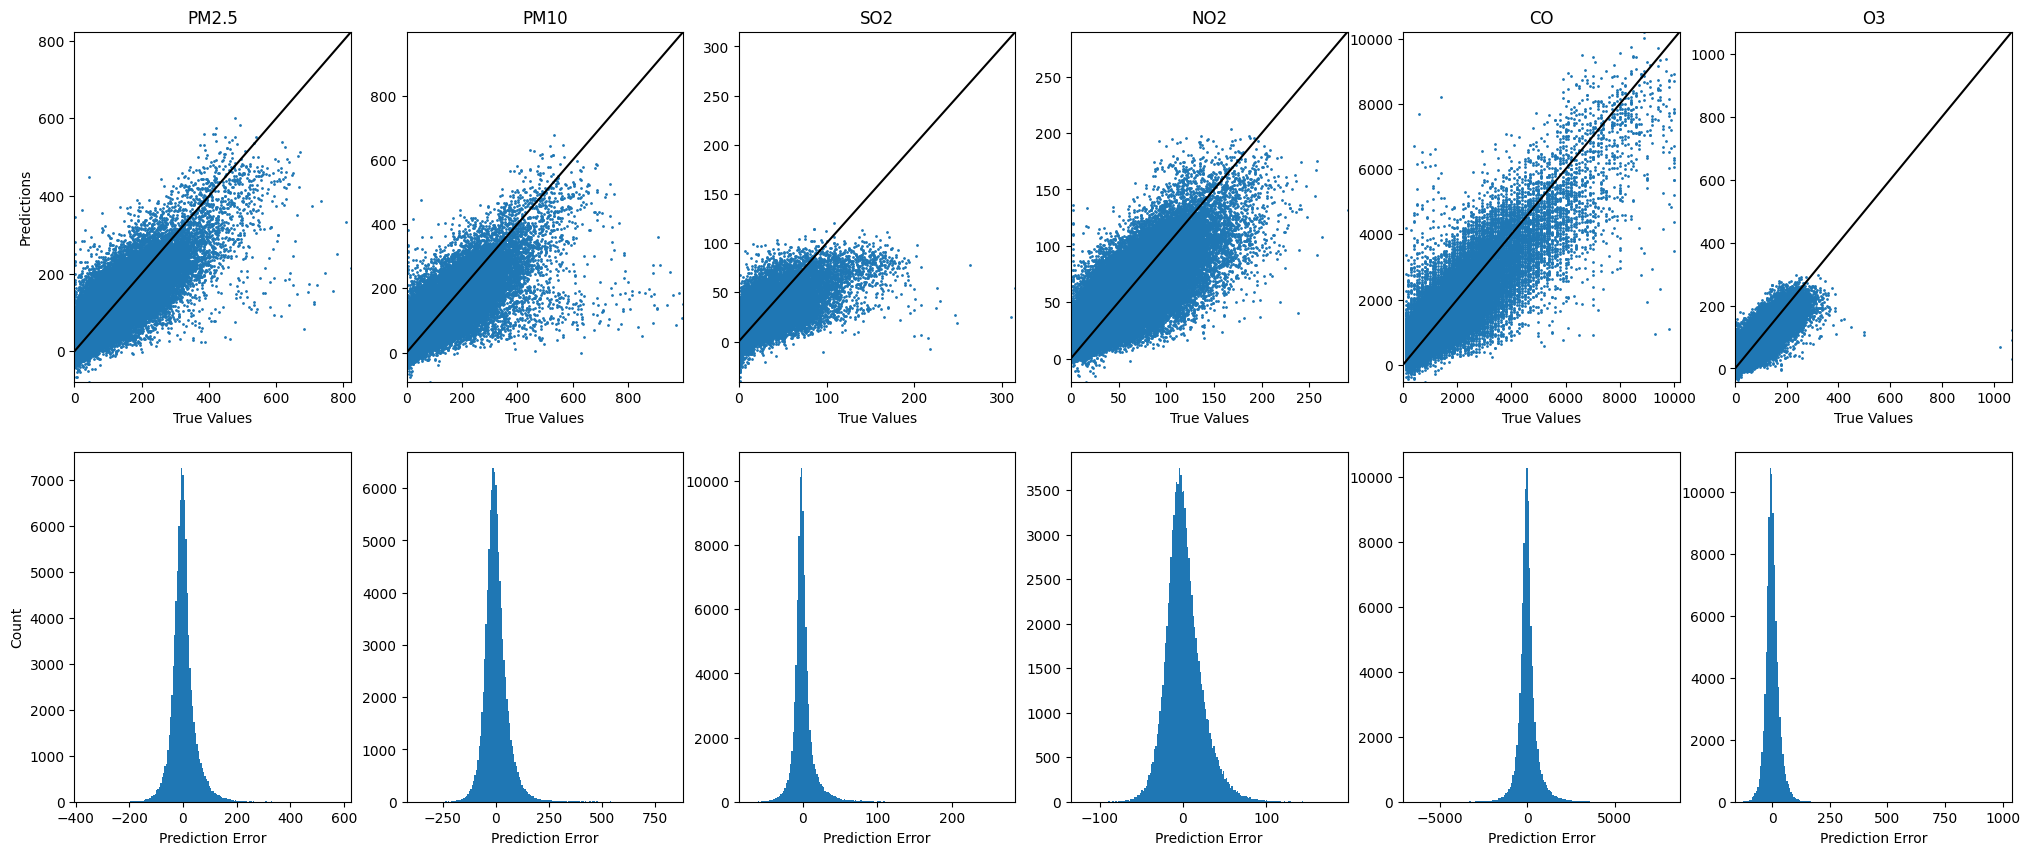

In [ ]:
plot_prediction_results(test_y,test_y_pred,target_data,200)

### **Best and worst predictions**
To select best and worst predictions the RMSE value for each test instance is computed.

In [ ]:
rmse_test_instances=root_mean_squared_error(test_y.transpose(),test_y_pred.transpose(),multioutput='raw_values')

rmse_test_instances_sorted_indices=np.argsort(rmse_test_instances)

The following code shows the best predictions returned by the model.

In [ ]:
with np.printoptions(precision=1, suppress=True):
  print('RMSE:')
  print(rmse_test_instances[rmse_test_instances_sorted_indices[:row_count]])

  print('True values:')
  print(test_y[rmse_test_instances_sorted_indices[:row_count]])

  print('Predicted values:')
  print(test_y_pred[rmse_test_instances_sorted_indices[:row_count]])

RMSE:
[2.5 3.  3.  3.3 3.5]
True values:
[[ 11.  35.   3.  11. 300.  74.]
 [ 16.  41.   2.  32. 400.  32.]
 [  6.  14.   2.  21. 300.  25.]
 [ 14.  21.   5.  34. 500.  47.]
 [  5.  33.   2.  17. 300.  82.]]
Predicted values:
[[  7.6  32.6  -0.9  12.1 299.8  71.6]
 [ 16.3  37.    3.2  33.5 399.9  26.1]
 [  8.5  15.6   3.1  22.7 296.4  19.6]
 [ 15.1  22.7  12.4  35.5 499.   49.1]
 [  7.1  27.4   1.2  13.3 298.1  77.6]]


The following code shows the worst predictions of the model.

In [ ]:
with np.printoptions(precision=1, suppress=True):
  print('RMSE:')
  print(rmse_test_instances[rmse_test_instances_sorted_indices[-row_count:]])

  print('True values:')
  print(test_y[rmse_test_instances_sorted_indices[-row_count:]])

  print('Predicted values:')
  print(test_y_pred[rmse_test_instances_sorted_indices[-row_count:]])

RMSE:
[2883.5 2897.7 2935.5 3413.8 3555.8]
True values:
[[  24.   90.    2.   53. 9000.    9.]
 [ 178.  214.    7.   92.  600.    2.]
 [  56.   81.   27.   64. 9500.   20.]
 [  82.  362.   32.   88. 9300.   22.]
 [ 119.  145.   39.   40. 9800.   19.]]
Predicted values:
[[  90.3  108.8   11.4   54.8 1937.2   33.8]
 [ 351.5  376.9   18.1  139.2 7693.8   -5.4]
 [ 117.9  128.    51.7   74.7 2310.    24.6]
 [  41.2   74.2   17.6   56.4  943.    19.4]
 [ 108.3  174.2   28.9   43.8 1090.8  109.1]]


# **Exercise 1**
Improve the performance of the DNN model. It is recommended to evaluate the following hyperparameters (listed in priority order):
1. the depth of the network and the number of neurons per hidden layer (*neuron_count_per_hidden_layer*);
2. the number of training epochs (*epoch_count*);
3. the optimization algorithm (*optimizer*);
4. the learning rate (*learning_rate*);
5. the mini-batch size (*batch_size*).

## Model creation


In [ ]:

dnn=build_dnn(train_x.shape[1],train_y.shape[1])

In [ ]:
dnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,406 (87.52 KB)

 Trainable params: 22,406 (87.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
dnn.compile(loss='mse', optimizer='SGD',metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])

In [ ]:
# epoch_count = 5
# batch_size = 512
# learning_rate=0.0001

# dnn = build_dnn(train_x.shape[1], train_y.shape[1])

# optimizer=keras.optimizers.SGD(learning_rate=learning_rate)
# dnn.compile(loss='mse', optimizer=optimizer,metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])

# history = dnn.fit(train_x, train_y,validation_data=(val_x,val_y), epochs=epoch_count, batch_size=batch_size,shuffle = True)

Epoch 1/2
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: nan - rmse: nan - val_loss: nan - val_rmse: nan
Epoch 2/2
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: nan - rmse: nan - val_loss: nan - val_rmse: nan


# **Exercise 2**
Solve another regression problem chosen from the following list:
- [Seoul Bike Sharing Demand Data Set](https://archive.ics.uci.edu/ml/datasets/Seoul+Bike+Sharing+Demand);
- [
Bike Sharing Dataset Data Set](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset);
- [PM2.5 Data of Five Chinese Cities Data Set](https://archive.ics.uci.edu/dataset/394/pm2+5+data+of+five+chinese+cities);
- [
Metro Interstate Traffic Volume Data Set](https://archive.ics.uci.edu/ml/datasets/Metro+Interstate+Traffic+Volume);
- [Wine Quality Data Set](https://archive.ics.uci.edu/ml/datasets/Wine+Quality).